In [9]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [10]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [11]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [42]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_DF_arr = data["pregrets_online"]
PREGRETS_random_DF_arr = data["pregrets_offline"]


fn = f"../results/RL/online_pregrets_fqi.npz"
data = np.load(fn)
print(data)
PREGRETS_RL_arr = data["pregret_list_time"]
PREGRETS_random_RL_arr = data["pregret_list_notime"]
Ts_RL = data["t_list"] - 200

fn = f"../results/RL/online_pregrets_sac.npz"
data = np.load(fn)
print(data)
PREGRETS_SAC_arr = data["pregret_list_time"]
PREGRETS_random_SAC_arr = data["pregret_list_notime"]
Ts_SAC = data["t_list"]- 200

fn = f"../results/RL/online_pregrets_sac_seeds_2.npz"
data = np.load(fn)
print(data)
PREGRETS_SAC_arr_2 = data["pregret_list_time"]
PREGRETS_random_SAC_arr_2 = data["pregret_list_notime"]
Ts_SAC_2 = data["t_list"]-200

NpzFile '../results/RL/online_pregrets_fqi.npz' with keys: pregret_list_notime, pregret_list_time, t_list
NpzFile '../results/RL/online_pregrets_sac.npz' with keys: pregret_list_notime, pregret_list_time, t_list
NpzFile '../results/RL/online_pregrets_sac_seeds_2.npz' with keys: pregret_list_notime, pregret_list_time, t_list


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_29296/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


[[0.26996331 0.02450598 0.         ... 0.00982435 0.00970222 0.00958946]
 [0.77851861 0.76947402 0.82641943 ... 0.         0.         0.        ]
 [1.09342528 1.10993587 1.09159596 ... 0.01225851 0.01188842 0.01150015]
 ...
 [0.80226315 0.81083367 0.82628898 ... 0.00542893 0.00533707 0.0052579 ]
 [0.91176296 0.92530537 0.88971203 ... 0.00982435 0.00970222 0.00958946]
 [0.47590737 0.47173301 0.55803146 ... 0.         0.         0.        ]]
(10, 9)
(10, 6)
9
[   0    0  128  256  512  750 1024 1250 1500 2048]
(10, 9)


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_29296/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_29296/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_29296/808698315.py:221: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax3.set_xlim([0, 100000])


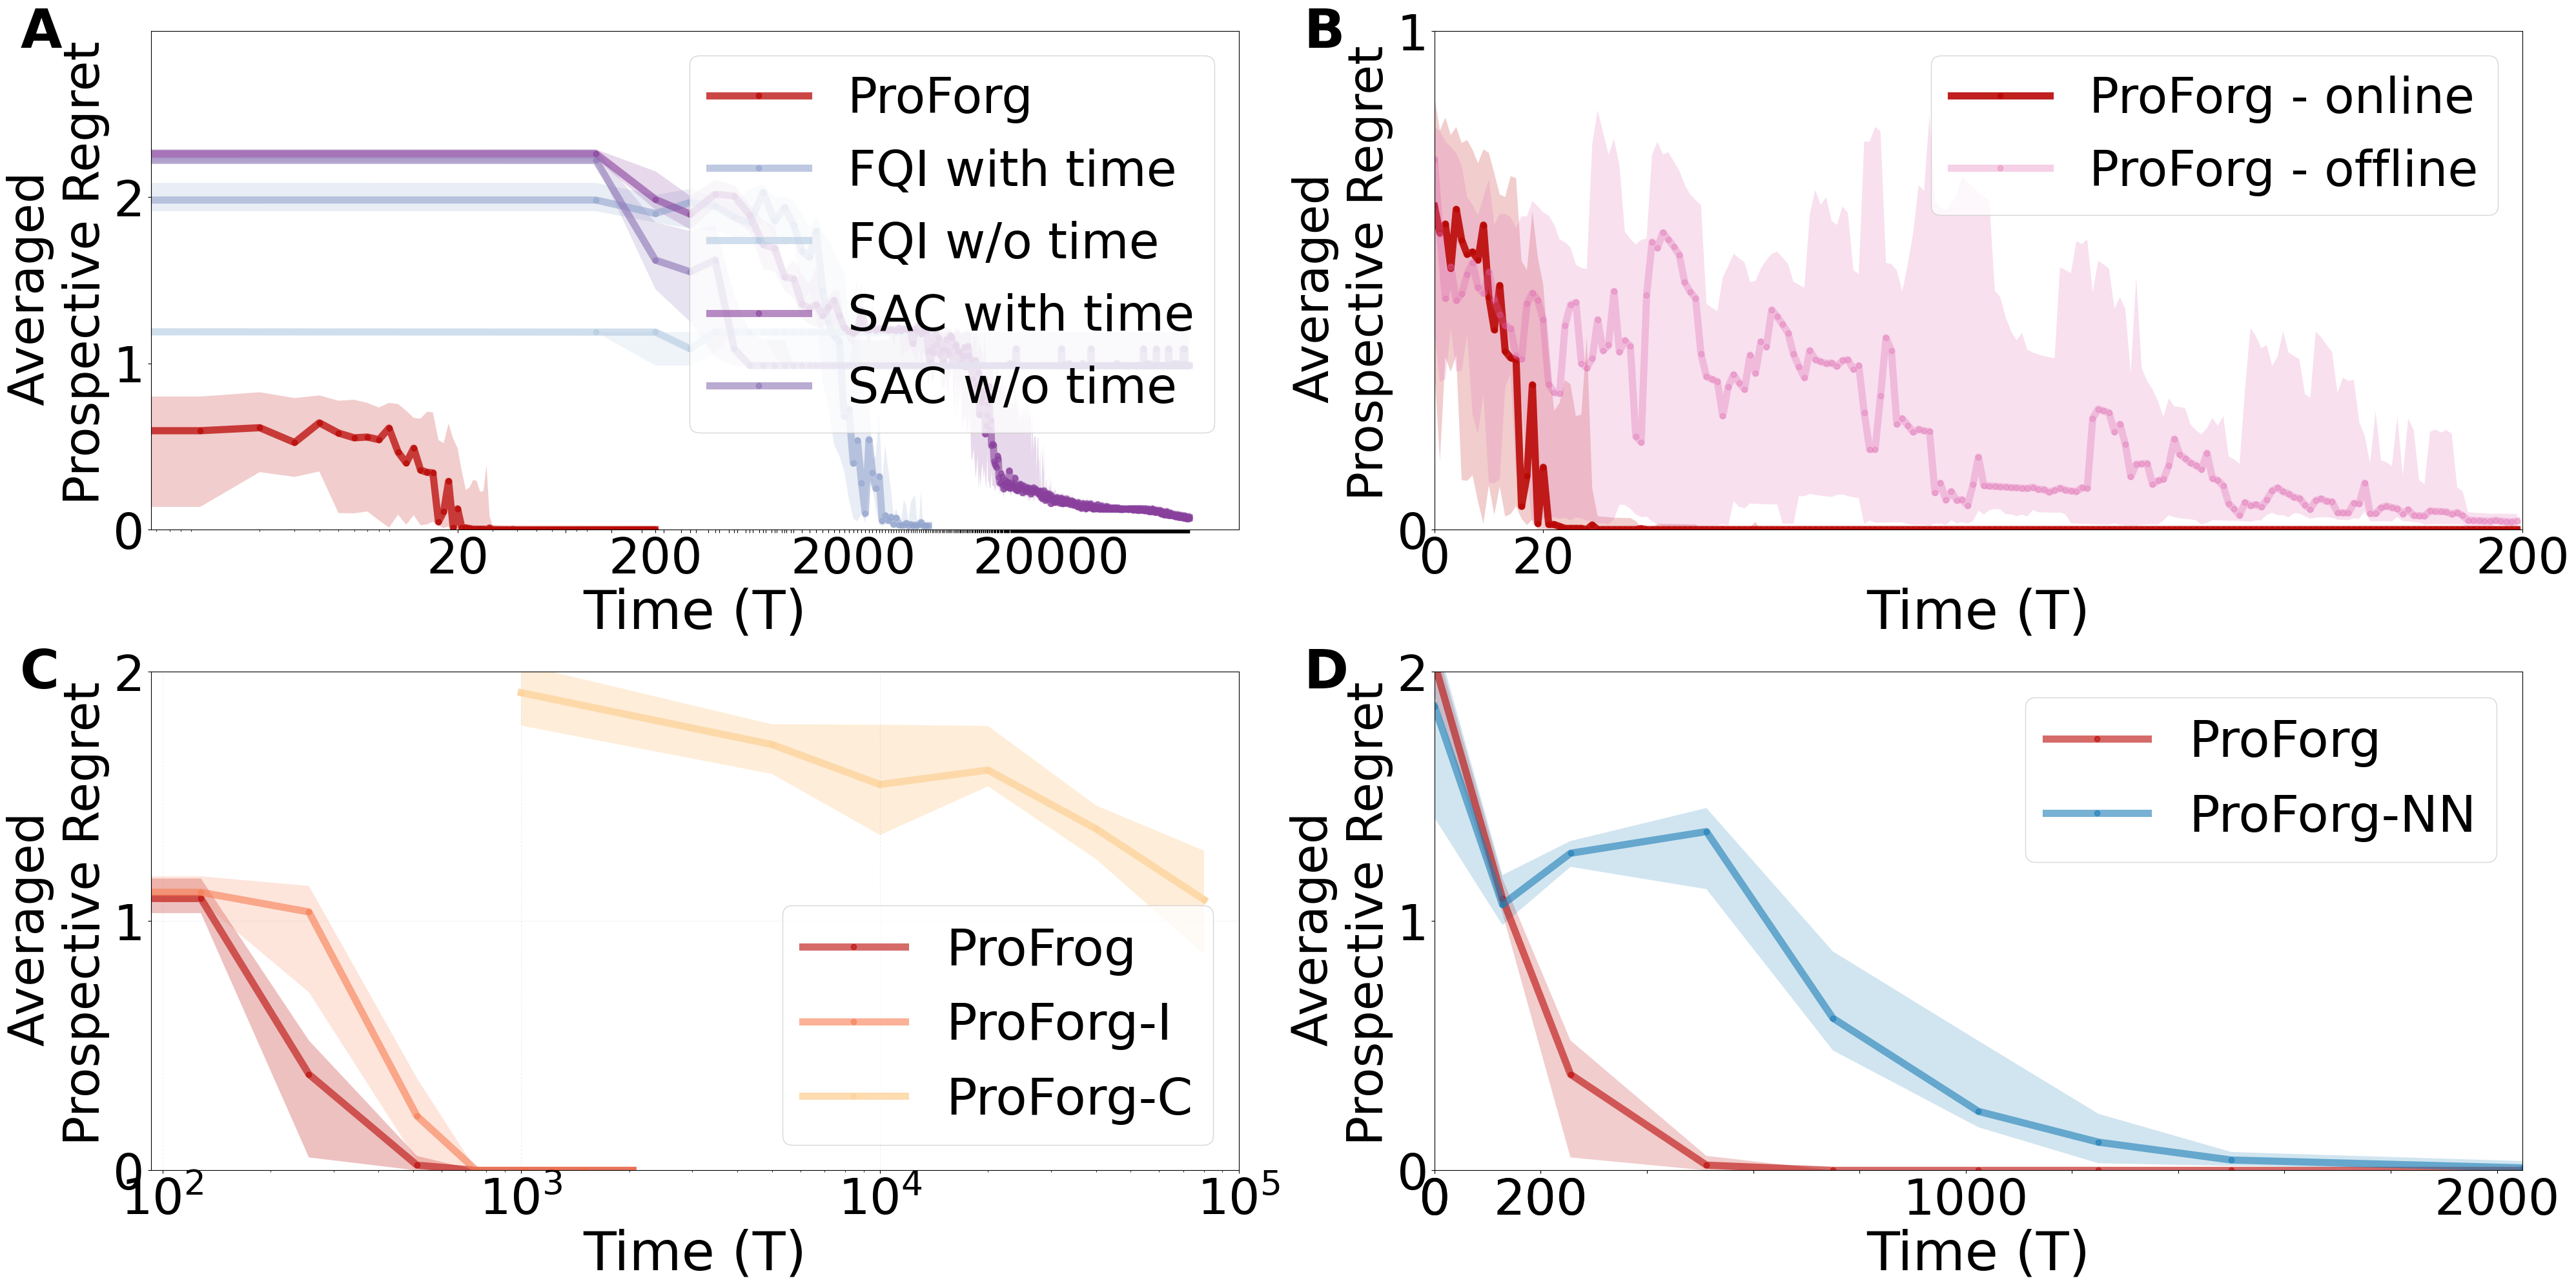

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# --- shared style ---
linewidth = 8
fontsize = 60

fig, axs = plt.subplots(2, 2, figsize=(40, 20))
(ax1, ax2), (ax3, ax4) = axs

# ============ SUBPLOT A ============ #
# (your first figure, now on ax1)

pvafm_df_offline, pafm_df, _, pvafm_df_online = get_close_colors("OrRd", start=0.25, delta=0.2, n=4)
rl_fqi_notime, rl_fqi_time, sac_fqi_notime, sac_fqi_time = get_close_colors("BuPu", start=0.3, delta=0.15, n=4)
sac_fqi_notime_2, sac_fqi_time_2 = get_close_colors("BuGn", start=0.4, delta=0.15, n=2)
rl_tql, _ = get_close_colors("Greens", start=0.6, delta=0.5, n=2)

colors = {
    "PAFM_RF_online": pvafm_df_online,
    "PAFM_RF_offline": pvafm_df_offline,
    "RL_FQI_notime": rl_fqi_notime,
    "RL_FQI_time": rl_fqi_time,
    "RL_SAC_notime": sac_fqi_notime,
    "RL_SAC_time": sac_fqi_time,
    "RL_SAC_notime_2": sac_fqi_notime_2,
    "RL_SAC_time_2": sac_fqi_time_2,
    "RL_TQL": rl_tql,
}

Ts_online = np.arange(200, 400, 1) - 200

median = np.median(PREGRETS_DF_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_DF_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_DF_arr, 75, axis=0)
ax1.plot(Ts_online, median[:200], color=colors["PAFM_RF_online"], lw=linewidth,
         marker='o', alpha=0.75, label='ProForg')
ax1.fill_between(Ts_online, q25[:200], q75[:200],
                 color=colors["PAFM_RF_online"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_RL_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_RL_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_RL_arr, 75, axis=0)
ax1.plot(Ts_RL[1:], median[1:], color=colors["RL_FQI_time"], lw=linewidth,
         marker='o', alpha=0.6, label='FQI with time')
ax1.fill_between(Ts_RL[1:], q25[1:], q75[1:],
                 color=colors["RL_FQI_time"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_RL_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_random_RL_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_random_RL_arr, 75, axis=0)
ax1.plot(Ts_RL[1:], median[1:], color=colors["RL_FQI_notime"], lw=linewidth,
         marker='o', alpha=0.6, label='FQI w/o time')
ax1.fill_between(Ts_RL[1:], q25[1:], q75[1:],
                 color=colors["RL_FQI_notime"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_SAC_arr_2, axis=0)
q25 = np.nanpercentile(PREGRETS_SAC_arr_2, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_SAC_arr_2, 75, axis=0)
ax1.plot(Ts_SAC_2[1:], median[1:], color=colors["RL_SAC_time"], lw=linewidth,
         marker='o', alpha=0.6, label='SAC with time')
ax1.fill_between(Ts_SAC_2[1:], q25[1:], q75[1:],
                 color=colors["RL_SAC_time"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_SAC_arr_2, axis=0)
q25 = np.nanpercentile(PREGRETS_random_SAC_arr_2, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_random_SAC_arr_2, 75, axis=0)
ax1.plot(Ts_SAC_2[1:], median[1:], color=colors["RL_SAC_notime"], lw=linewidth,
         marker='o', alpha=0.6, label='SAC w/o time')
ax1.fill_between(Ts_SAC_2[1:], q25[1:], q75[1:],
                 color=colors["RL_SAC_notime"], alpha=0.20, edgecolor="none")

ax1.set_xscale('log')

xticks = [i for i in np.arange(20, 1000, 50)] + \
         [i for i in np.arange(10000, 5000, 1000)] + \
         [i for i in np.arange(200, 100000, 100)]
xticklabels = [str(v) if v in ['0', 20, 200, 2000, 20000, 20000] else ""
               for i, v in enumerate(xticks)]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticklabels, fontsize=fontsize-5)
ax1.set_ylim([0, 3])
ax1.set_yticks([0, 1, 2])
ax1.tick_params(axis='y', labelsize=fontsize-5)
ax1.set_xlabel("Time (T)", fontsize=fontsize)
ax1.set_ylabel("Averaged \n Prospective Regret", fontsize=fontsize-5)
ax1.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=fontsize-5)

# ============ SUBPLOT B ============ #
# (your second figure, now on ax2)

fn = f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]
print(PREGRETS_arr)

pvafm_df_offline, _ = get_close_colors("PuRd", start=0.5, delta=0.65, n=2)
_, pvafm_df_online = get_close_colors("OrRd", start=0.2, delta=0.65, n=2)
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25, n=2)
rl_fqi, _ = get_close_colors("Purples", start=0.8, delta=0.5, n=2)
rl_tql, _ = get_close_colors("Greens", start=0.6, delta=0.5, n=2)

colors = {
    "PVAFM_RF_offline": pvafm_df_offline,
    "PVAFM_RF_online": pvafm_df_online,
    "PAFM_oh_NN": pafm_nn,
    "PAFM_opt_NN": pafm_nn_opt,
    "RL_FQI": rl_fqi,
    "RL_TQL": rl_tql,
}

Ts_online = np.arange(200, 400, 1) - 200

median = np.median(PREGRETS_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_arr, 75, axis=0)
ax2.plot(Ts_online, median[:200], color=colors["PVAFM_RF_online"], lw=linewidth,
         marker='o', alpha=0.9, label='ProForg - online')
ax2.fill_between(Ts_online, q25[:200], q75[:200],
                 color=colors["PVAFM_RF_online"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)
ax2.plot(Ts_online, median[:200], color=colors["PVAFM_RF_offline"], lw=linewidth,
         marker='o', alpha=0.3, label='ProForg - offline')
ax2.fill_between(Ts_online, q25[:200], q75[:200],
                 color=colors["PVAFM_RF_offline"], alpha=0.20, edgecolor="none")

ax2.set_xticks([0, 20, 200])
ax2.set_xticklabels([0, 20, 200], fontsize=fontsize-5)
ax2.set_xlim([0, 200])
ax2.set_ylim([0, 1])
ax2.set_yticks([0, 1])
ax2.tick_params(axis='y', labelsize=fontsize-5)
ax2.set_xlabel("Time (T)", fontsize=fontsize)
ax2.set_ylabel("Averaged \n Prospective Regret", fontsize=fontsize-6)
ax2.legend(fontsize=fontsize-5)

# ============ SUBPLOT C ============ #
# (your third figure, now on ax3)

Ts_DF = [0]+[2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
Ts_DF_final = [0,128,256, 512, 750, 1024, 1250, 1500, 2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time0_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        if T not in Ts_DF_final:
            pass
        else:
            irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
            preward = compute_normalized_future_rewards(irewards,100,0.5,normalization=True)
            path, ireward_opt = path_opt(states[k,0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization=True)
            pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

Ts_PVFM = [1000,5000,10000,20000,40000,80000]
fn = f"../results/PVFM/RF_oh_w_time1000_80000_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_PVFM_arr = data["pregrets"]
print(PREGRETS_PVFM_arr.shape)

fn = f"../results/PVAFM/GBT_pregrets_gamma0.9_oh_w_time0_2048_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_RF_arr = data["pregrets"]
Ts = data['t_list']
Ts = Ts[1:]
# Ts[0] = 1
print(len(Ts))

pavfm_df, pafm_df, pvfm_df = get_close_colors("OrRd", start=0.85, delta=-0.3, n=3)

colors = {
    "PAFM_oh_RF": pafm_df,
    "PVFM_oh_RF": pvfm_df,
    "PAVFM_RF": pavfm_df,
}

median = np.nanmedian(PREGRETS_RF_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_RF_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_RF_arr, 75, axis=0)
ax3.plot(Ts, median, color=colors["PAVFM_RF"], lw=linewidth,
         alpha=0.6, label='ProFrog', marker='o')
ax3.fill_between(Ts, q25, q75,
                 color=colors["PAVFM_RF"], alpha=0.25, edgecolor="none")

median = np.median(PREGRETS_PAFM_DF_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
ax3.plot(Ts, median, color=colors["PAFM_oh_RF"], lw=linewidth,
         marker='o', alpha=0.6, label='ProForg-I')
ax3.fill_between(Ts, q25, q75,
                 color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")

median = np.nanmedian(PREGRETS_PVFM_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_PVFM_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_PVFM_arr, 75, axis=0)
ax3.plot(Ts_PVFM, median, color=colors["PVFM_oh_RF"], lw=linewidth,
         marker='o', alpha=0.8, label='ProForg-C')
ax3.fill_between(Ts_PVFM, q25, q75,
                 color=colors["PVFM_oh_RF"], alpha=0.40, edgecolor="none")

ax3.set_xlabel("Time (T)", fontsize=fontsize)
ax3.set_ylabel("Averaged \n Prospective Regret", fontsize=fontsize-5)
ax3.set_xscale('log')
ax3.set_xlim([0, 100000])
ax3.set_ylim([0, 2])
ax3.set_yticks([0, 1, 2])
ax3.tick_params(axis='x', labelsize=fontsize-5)
ax3.tick_params(axis='y', labelsize=fontsize-5)
ax3.legend(loc='lower right', fontsize=fontsize-3)
ax3.grid(True, linestyle='--', alpha=0.2)

# ============ SUBPLOT D ============ #
# (your 4th block as pasted, now on ax4; currently same code as C)

fn = f"../results/PVAFM/GBT_pregrets_gamma0.9_oh_w_time0_2048_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_DF_arr = data["pregrets"]
Ts = data['t_list']
Ts = Ts[1:]
print(data['t_list'])

fn = f"../results/OnlinePAFM/PVAFM_NN_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_NN_arr = data["pregrets_online"]
# Ts_RL = data["t_list"]


fn = f"../results/OnlinePAFM/PVAFM_NN_oh_w_time0_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_NN_init_arr = data["pregrets"]
PREGRETS_NN_arr = np.hstack([PREGRETS_NN_init_arr,PREGRETS_NN_arr])
print(PREGRETS_NN_arr.shape)


pafm_df, pvafm_df = get_close_colors("OrRd", start=0.45, delta=0.4, n=2)
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25, n=2)
rl_fqi, rl_fqi_notime = get_close_colors("Purples", start=0.7, delta=-0.3, n=2)
rl_tql, _ = get_close_colors("Greens", start=0.6, delta=0.5, n=2)

colors_D = {
    "PVAFM_oh_RF": pvafm_df,
    "PVAFM_oh_NN": pafm_nn,
}

# DF (RF) curve
median = np.median(PREGRETS_DF_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_DF_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_DF_arr, 75, axis=0)
ax4.plot(Ts, median, color=colors_D["PVAFM_oh_RF"], lw=linewidth,
         marker='o', alpha=0.6, label='ProForg')
ax4.fill_between(Ts, q25, q75,
                 color=colors_D["PVAFM_oh_RF"], alpha=0.20, edgecolor="none")

# NN curve
median = np.median(PREGRETS_NN_arr, axis=0)
q25 = np.nanpercentile(PREGRETS_NN_arr, 25, axis=0)
q75 = np.nanpercentile(PREGRETS_NN_arr, 75, axis=0)
ax4.plot(Ts, median, color=colors_D["PVAFM_oh_NN"], lw=linewidth,
         marker='o', alpha=0.6, label='ProForg-NN')
ax4.fill_between(Ts, q25, q75,
                 color=colors_D["PVAFM_oh_NN"], alpha=0.20, edgecolor="none")

ax4.set_xlabel("Time (T)", fontsize=fontsize)
ax4.set_ylabel("Averaged \n Prospective Regret", fontsize=fontsize-5)

xticks = [i for i in np.arange(0, 2000, 200)] + [0, 200, 2000, 20000]
xticklabels = [str(v) if v in [0, 20, 200, 1000, 2000, 20000] else ""
               for i, v in enumerate(xticks)]
ax4.set_xticks(xticks)
ax4.set_xticklabels(xticklabels, fontsize=fontsize-5)

ax4.set_ylim([0, 2])
ax4.set_xlim([0, 2048])
ax4.set_yticks([0, 1, 2])
ax4.tick_params(axis='y', labelsize=fontsize-5)
ax4.legend(fontsize=fontsize-3)


# ============ PANEL LABELS A, B, C, D ============ #
labels = ['A', 'B', 'C', 'D']
for ax, lab in zip(axs.flatten(), labels):
    ax.text(-0.12, 1.05, lab, transform=ax.transAxes,
            fontsize=fontsize, fontweight='bold',
            va='top', ha='left')

fig.tight_layout()
fig.savefig("ProForg_4panel.png", dpi=300, bbox_inches="tight")
plt.show()
